# Segmentação de Clientes com Análise RFM - E-Commerce Brasileiro
### **Pipeline Completo**: **`Merge`**  ->  **`EDA`**  ->  **`Segmentação por Quartis`**  ->  **`K-Means`**  ->  **`Recomendações de Marketing`**

**Autor:** Lucas Coutinho Boros  
**Data:** Maio/2026  
**Dataset:** [Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)  
**GitHub:** [Lucas-Coutinhob](https://github.com/Lucas-Coutinhob)

---

## Contexto de Negócio

A **análise RFM** (Recency, Frequency, Monetary Value) é uma técnica de segmentação de clientes baseada em dados históricos de compras. Ela classifica cada cliente em três dimensões:

| Dimensão | Pergunta | Interpretação |
|----------|----------|---------------|
| **Recency (R)** | Quando foi a última compra? | Clientes recentes têm maior probabilidade de comprar novamente |
| **Frequency (F)** | Quantas vezes comprou? | Clientes frequentes são mais engajados e leais |
| **Monetary (M)** | Quanto gastou no total? | Clientes de alto valor merecem atenção diferenciada |

### Objetivo
Segmentar a base de ~96 mil clientes do e-commerce Olist para identificar:
- Quais clientes são VIP e merecem programas de fidelidade
- Quais estão em risco de churn e precisam de reengajamento
- Onde concentrar o investimento de marketing para maximizar ROI

### Estrutura do Projeto
```
1. Setup e Carregamento dos Dados
2. Merge dos Datasets (5 tabelas → 1 base consolidada)
3. EDA Completa (missing, outliers, distribuições, temporal)
4. Feature Engineering — Cálculo de R, F e M
5. Segmentação por Quartis (método clássico)
6. Segmentação por K-Means (método alternativo)
7. Análise Comparativa dos Segmentos
8. Recomendações de Marketing por Segmento
9. Conclusões e Próximos Passos
```

# **Etapa 1:** ***Setup e Carregamento dos Dados***

### 1.1 Instalação e Importação de Pacotes

In [1]:
# Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import squarify
import plotly.express as px
import plotly.graph_objects as go
from datetime import datetime, timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
import os

# Configurações de exibição 
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Pacotes carregados com sucesso.")

Pacotes carregados com sucesso.


### 1.2 Carregamento dos Datasets

O dataset Olist é composto por múltiplas tabelas relacionais. Para a análise RFM, precisamos de 5 tabelas:

| Tabela | Conteúdo | Chave |
|--------|----------|-------|
| `orders` | Pedidos (datas, status) | `order_id`, `customer_id` |
| `order_payments` | Pagamentos (valores, método) | `order_id` |
| `customers` | Clientes (ID único, localização) | `customer_id`, `customer_unique_id` |
| `order_items` | Itens do pedido (preço, frete) | `order_id`, `product_id` |
| `products` | Produtos (categoria, dimensões) | `product_id` |

In [2]:
# Carregamento via API Kaggle (se configurado) 
# Tenta baixar via kagglehub; se não tiver credenciais, usa pasta local
try:
    import kagglehub
    DATA_PATH = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
    print(f"Dataset baixado via API: {DATA_PATH}")
except Exception:
    DATA_PATH = "dados/"
    print(f"Carregando dos arquivos locais: {DATA_PATH}")

# Carregamento das 5 tabelas 
df_orders     = pd.read_csv(f"{DATA_PATH}/olist_orders_dataset.csv")
df_payments   = pd.read_csv(f"{DATA_PATH}/olist_order_payments_dataset.csv")
df_customers  = pd.read_csv(f"{DATA_PATH}/olist_customers_dataset.csv")
df_items      = pd.read_csv(f"{DATA_PATH}/olist_order_items_dataset.csv")
df_products   = pd.read_csv(f"{DATA_PATH}/olist_products_dataset.csv")

# Verificação imediata 
datasets = {
    'orders':    df_orders,
    'payments':  df_payments,
    'customers': df_customers,
    'items':     df_items,
    'products':  df_products
}

for nome, df in datasets.items():
    print(f"{nome:12s} → {df.shape[0]:>7,} linhas | {df.shape[1]:>2} colunas | "
          f"{df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Dataset baixado via API: C:\Users\lucas\.cache\kagglehub\datasets\olistbr\brazilian-ecommerce\versions\2
orders       →  99,441 linhas |  8 colunas | 52.9 MB
payments     → 103,886 linhas |  5 colunas | 16.2 MB
customers    →  99,441 linhas |  5 colunas | 26.6 MB
items        → 112,650 linhas |  7 colunas | 36.0 MB
products     →  32,951 linhas |  9 colunas | 6.3 MB


### 1.3 Inspeção Inicial 

> Verificando a Estrutura de Cada Tabela

Investigando a estrutura individual de cada tabela com foco em verificar: **tipos de dados**, **valores ausentes** e **cardinalidade**.

In [3]:
# Inspeção da tabela ORDERS 
print("=" * 23)
print("ORDERS — Pedidos")
print("=" * 23)
print(f"Shape: {df_orders.shape}")
print(f"\nTipos de dados:")
print(df_orders.dtypes)
print(f"\nValores ausentes:")
print(df_orders.isnull().sum()[df_orders.isnull().sum() > 0])
print(f"\nStatus dos pedidos:")
print(df_orders['order_status'].value_counts())
print(f"\nAmostra:")
df_orders.sample(3)

ORDERS — Pedidos
Shape: (99441, 8)

Tipos de dados:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Valores ausentes:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Status dos pedidos:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Amostra:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
84522,a5a32befe5eebcc26930e213ffdf3369,3705330ddc148deb33331cf451b38b55,delivered,2017-02-20 14:21:09,2017-02-20 15:00:11,2017-02-21 14:00:02,2017-02-23 10:07:42,2017-03-17 00:00:00
67667,b4eed0937529c145938bdfcb03ed14d2,c4dc2f61b3a3548a9a879a265f8fdc92,delivered,2017-11-05 01:22:08,2017-11-05 01:35:27,2017-11-07 19:08:38,2017-11-09 18:08:04,2017-11-24 00:00:00
24345,6d8102dfb9acad707f6e15b413270621,cbc1a4a40e7aa73b36fc4ba3e3bb663c,delivered,2018-04-07 21:15:34,2018-04-08 21:10:54,2018-04-10 00:28:47,2018-04-10 17:19:22,2018-04-20 00:00:00


In [4]:
# Inspeção da tabela PAYMENTS 
print("=" * 23)
print("PAYMENTS — Pagamentos")
print("=" * 23)
print(f"Shape: {df_payments.shape}")
print(f"\nTipos de dados:")
print(df_payments.dtypes)
print(f"\nValores ausentes: {df_payments.isnull().sum().sum()}")
print(f"\nMétodos de pagamento:")
print(df_payments['payment_type'].value_counts())
print(f"\nEstatísticas do payment_value:")
print(df_payments['payment_value'].describe())
print("\n=== Amostra ===\n")
print(df_payments.sample(3))

PAYMENTS — Pagamentos
Shape: (103886, 5)

Tipos de dados:
order_id                    str
payment_sequential        int64
payment_type                str
payment_installments      int64
payment_value           float64
dtype: object

Valores ausentes: 0

Métodos de pagamento:
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64

Estatísticas do payment_value:
count   103886.00
mean       154.10
std        217.49
min          0.00
25%         56.79
50%        100.00
75%        171.84
max      13664.08
Name: payment_value, dtype: float64

=== Amostra ===

                               order_id  payment_sequential payment_type  \
91074  bdbe430ba78a7cff2db4ac139372d5b5                   1  credit_card   
81609  40bf12930df251761b91291590dbe45b                   1  credit_card   
6452   65beeed06eb791b6c1026364455fdca3                   1  credit_card   

       payment_installments  payment_value  


In [5]:
# Inspeção da tabela CUSTOMERS 
print("=" * 23)
print("CUSTOMERS — Clientes")
print("=" * 23)
print(f"Shape: {df_customers.shape}")
print(f"customer_id únicos:        {df_customers['customer_id'].nunique():,}")
print(f"customer_unique_id únicos: {df_customers['customer_unique_id'].nunique():,}")
print(f"\nValores ausentes: {df_customers.isnull().sum().sum()}")
print(f"\nTop 5 estados:")
print(df_customers['customer_state'].value_counts().head())
print("\n=== Amostra ===\n")
print(df_customers.sample(3))

CUSTOMERS — Clientes
Shape: (99441, 5)
customer_id únicos:        99,441
customer_unique_id únicos: 96,096

Valores ausentes: 0

Top 5 estados:
customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
Name: count, dtype: int64

=== Amostra ===

                            customer_id                customer_unique_id  \
6419   93c07a27854a22f74c7ad4f943585bce  a1037cdfc5b17d41ac68e20a1c4ec4fd   
81423  7f230bc3e608f26f8ecaa710abd5d2d2  c3c223cb6c2815575f6011ba39740afc   
49805  9359277ae2c0ab1772190a4b769f148e  80721bef26b8e127ac080a297b683707   

       customer_zip_code_prefix customer_city customer_state  
6419                      73025      brasilia             DF  
81423                     75170   goianapolis             GO  
49805                     49050       aracaju             SE  


In [6]:
# Inspeção das tabelas ITEMS  
print("=" * 60)
print("ITEMS — Itens dos pedidos")
print("=" * 60)
print(f"Shape: {df_items.shape}")
print(f"Valores ausentes: {df_items.isnull().sum().sum()}")
print(f"\nEstatísticas de preço:")
print(df_items['price'].describe())
print("\n=== Amostra ===\n")
print(df_items.sample(3))



ITEMS — Itens dos pedidos
Shape: (112650, 7)
Valores ausentes: 0

Estatísticas de preço:
count   112650.00
mean       120.65
std        183.63
min          0.85
25%         39.90
50%         74.99
75%        134.90
max       6735.00
Name: price, dtype: float64

=== Amostra ===

                               order_id  order_item_id  \
8001   122c0857cda2681ca041cded5e95741a              2   
33719  4c566742b96f3f068f5058e7919c2842              1   
43335  6288c084b4b8b9ed59cddc6793eba928              1   

                             product_id                         seller_id  \
8001   6ee7217ab647f3c2b4a5161c75cadab3  cca3071e3e9bb7d12640c9fbe2301306   
33719  6cc44821f36f3156c782da72dd634e47  da8622b14eb17ae2831f4ac5b9dab84a   
43335  bc4a074ab7a7ff14e98fa64671a79dc0  4e17c65a516f69d023a2ae78b84f28d6   

       shipping_limit_date  price  freight_value  
8001   2017-06-27 03:50:32   8.90          11.85  
33719  2017-12-06 08:35:55  99.90          17.95  
43335  2018-02-07 02:11:57

In [7]:
# Inspeção da Tabela Produtos
print(f"\n{'=' * 60}")
print("PRODUCTS — Produtos")
print(f"{'=' * 60}")
print(f"Shape: {df_products.shape}")
print(f"\nValores ausentes:")
print(df_products.isnull().sum()[df_products.isnull().sum() > 0])
print(f"\nTop 5 categorias:")
print(df_products['product_category_name'].value_counts().head())
print("\n=== Amostra ===\n")
print(df_products.sample(3))


PRODUCTS — Produtos
Shape: (32951, 9)

Valores ausentes:
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

Top 5 categorias:
product_category_name
cama_mesa_banho          3029
esporte_lazer            2867
moveis_decoracao         2657
beleza_saude             2444
utilidades_domesticas    2335
Name: count, dtype: int64

=== Amostra ===

                             product_id product_category_name  \
5739   be4cd8597e81008f1372c387f620e0a9    relogios_presentes   
10237  691e72a37278e33ac031c3976358446b            brinquedos   
12632  7cfb84c1323fb861a17478de42b1839f       cama_mesa_banho   

       product_name_lenght  product_description_lenght  product_photos_qty  \
5739                 46.00                      655.00                1.00   
10237

### 1.4 Dicionário de Dados -  Tabelas Originais

> Referência rápida para compreensão dos campos. Termos em inglês são padrão do dataset Olist (Kaggle).

---

**📋 ORDERS** — Registro de cada pedido realizado na plataforma

| Coluna | Tipo | Descrição |
|--------|------|-----------|
| `order_id` | str | Identificador único do pedido |
| `customer_id` | str | Chave que liga o pedido ao cliente. Um mesmo cliente pode ter diferentes `customer_id` em pedidos distintos — por isso existe o `customer_unique_id` na tabela customers |
| `order_status` | str | Estado atual do pedido: `delivered` (entregue), `shipped` (enviado/em trânsito), `canceled` (cancelado), `unavailable` (indisponível), `invoiced` (nota fiscal emitida), `processing` (em processamento), `created` (criado) e `approved` (pagamento aprovado) |
| `order_purchase_timestamp` | str → datetime | Data e hora exatas em que o cliente finalizou a compra |
| `order_approved_at` | str → datetime | Data e hora em que o pagamento foi aprovado pela operadora. Pode ser NaN se o pedido foi cancelado antes da aprovação |
| `order_delivered_carrier_date` | str → datetime | Data em que o vendedor entregou o produto à transportadora. NaN se o pedido não chegou a ser despachado |
| `order_delivered_customer_date` | str → datetime | Data em que o cliente recebeu o produto. NaN se o pedido ainda não foi entregue ou foi cancelado |
| `order_estimated_delivery_date` | str → datetime | Data estimada de entrega informada ao cliente no momento da compra |

---

**💳 PAYMENTS** — Detalhes de pagamento de cada pedido

| Coluna | Tipo | Descrição |
|--------|------|-----------|
| `order_id` | str | Identificador do pedido (chave de ligação com orders) |
| `payment_sequential` | int | Sequência do pagamento dentro do pedido. Um pedido pode ter mais de um pagamento (ex: parte no cartão + parte no voucher), e cada um recebe um número sequencial (1, 2, 3...) |
| `payment_type` | str | Método de pagamento: `credit_card` (cartão de crédito), `boleto` (boleto bancário), `voucher` (vale/cupom de desconto), `debit_card` (cartão de débito), `not_defined` (não definido) |
| `payment_installments` | int | Número de parcelas escolhido pelo cliente. Ex: 1 = à vista, 3 = 3x no cartão, 10 = 10x no cartão. Comum no e-commerce brasileiro — boleto é sempre 1 |
| `payment_value` | float | Valor pago nesta parcela/método (em Reais R$). A soma de todos os `payment_value` de um pedido = valor total pago pelo cliente |

---

**👤 CUSTOMERS** — Cadastro dos clientes

| Coluna | Tipo | Descrição |
|--------|------|-----------|
| `customer_id` | str | Identificador do cliente vinculado a um pedido específico. Muda a cada novo pedido do mesmo cliente |
| `customer_unique_id` | str | Identificador real e permanente do cliente. É este campo que usamos para agrupar compras por pessoa na análise RFM. No dataset: 99.441 `customer_id` vs 96.096 `customer_unique_id` → ~3.345 clientes fizeram mais de 1 pedido |
| `customer_zip_code_prefix` | int | Prefixo do CEP do cliente (5 primeiros dígitos) |
| `customer_city` | str | Cidade do cliente |
| `customer_state` | str | Estado do cliente (sigla UF: SP, RJ, MG, etc.) |

---

**📦 ITEMS** — Itens contidos em cada pedido

| Coluna | Tipo | Descrição |
|--------|------|-----------|
| `order_id` | str | Identificador do pedido (chave de ligação) |
| `order_item_id` | int | Número sequencial do item dentro do pedido. Se um pedido tem 3 produtos, terá linhas com `order_item_id` = 1, 2, 3 |
| `product_id` | str | Identificador único do produto |
| `seller_id` | str | Identificador do vendedor que forneceu o produto (marketplace — cada produto pode vir de um vendedor diferente) |
| `shipping_limit_date` | str | Data limite para o vendedor despachar o produto à transportadora |
| `price` | float | Preço unitário do produto (em R$) |
| `freight_value` | float | Valor do frete cobrado por este item (em R$). Cada item tem seu próprio frete, pois podem vir de vendedores/localidades diferentes |

---

**🏷️ PRODUCTS** — Catálogo de produtos

| Coluna | Tipo | Descrição |
|--------|------|-----------|
| `product_id` | str | Identificador único do produto |
| `product_category_name` | str | Categoria do produto em português (ex: `cama_mesa_banho`, `beleza_saude`, `esporte_lazer`). 610 produtos sem categoria cadastrada |
| `product_name_lenght` | float | Quantidade de caracteres no nome do produto |
| `product_description_lenght` | float | Quantidade de caracteres na descrição do produto |
| `product_photos_qty` | float | Número de fotos publicadas no anúncio |
| `product_weight_g` | float | Peso do produto em gramas |
| `product_length_cm` | float | Comprimento do produto em centímetros |
| `product_height_cm` | float | Altura do produto em centímetros |
| `product_width_cm` | float | Largura do produto em centímetros |

# **Etapa 2:** ***Merge dos Datasets***

A estratégia de merge segue a lógica relacional do banco de dados do Olist:

```
orders ──(order_id)──► payments      → valor pago por pedido
orders ──(customer_id)──► customers  → customer_unique_id (identidade real)
items  ──(product_id)──► products    → categoria do produto
orders ──(order_id)──► items         → itens de cada pedido
```

**Decisão:** Usaremos `left join` a partir de `orders` para preservar todos os pedidos, mesmo que alguma tabela secundária tenha dados faltantes.

**Atenção à granularidade:** 
- `orders` tem 1 linha por pedido
- `payments` pode ter N linhas por pedido (múltiplos métodos de pagamento)
- `items` tem N linhas por pedido (múltiplos produtos)

Precisamos agregar `payments` e `items` ANTES do merge para manter granularidade de 1 linha por pedido.

### 2.1 Agregar PAYMENTS por order_id 

In [8]:
# Um pedido pode ter múltiplos pagamentos (ex: cartão + boleto)
# Agregamos para obter o valor total pago por pedido
payments_agg = df_payments.groupby('order_id').agg(
    payment_value_total=('payment_value', 'sum'),
    payment_installments_max=('payment_installments', 'max'),
    payment_methods_count=('payment_type', 'nunique'),
    payment_type_main=('payment_type', 'first')  # método principal
).reset_index()

print(f"Payments agregados: {payments_agg.shape}")
print(f"Verificação: order_id únicos = {payments_agg['order_id'].nunique():,}")
payments_agg.head()

Payments agregados: (99440, 5)
Verificação: order_id únicos = 99,440


,order_id,payment_value_total,payment_installments_max,payment_methods_count,payment_type_main
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card


### 2.2  Agregar ITEMS por order_id 

In [9]:
# Um pedido pode ter múltiplos itens
# Agregamos para obter: total de itens, valor total, frete total
items_agg = df_items.groupby('order_id').agg(
    items_count=('order_item_id', 'max'),
    items_price_total=('price', 'sum'),
    items_freight_total=('freight_value', 'sum'),
    product_id_first=('product_id', 'first')  # produto principal (para categoria)
).reset_index()

print(f"Items agregados: {items_agg.shape}")
items_agg.head()

Items agregados: (98666, 5)


,order_id,items_count,items_price_total,items_freight_total,product_id_first
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,4244733e06e7ecb4970a6e2683c13e61
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,e5f2d52b802189ee658865ca93d83a8f
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,c777355d18b72b67abbeef9df44fd0fd
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,7634da152a4610f1595efa32f14722fc
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,ac6c3623068f30de03045865e4e10089


### Dicionário — Colunas Criadas na Agregação

> Campos derivados que não existem no dataset original. Foram criados durante a etapa de agregação para consolidar informações no nível de 1 linha por pedido.

**Agregação de PAYMENTS** (`payments_agg`)

| Coluna criada | Origem | Cálculo | Descrição |
|---------------|--------|---------|-----------|
| `payment_value_total` | `payment_value` | `sum` por `order_id` | Valor total pago pelo cliente no pedido, somando todos os métodos de pagamento. Ex: se pagou R$ 100 no cartão + R$ 50 em voucher, o total é R$ 150 |
| `payment_installments_max` | `payment_installments` | `max` por `order_id` | Maior número de parcelas usado no pedido. Se o cliente pagou parte em 6x no cartão e parte à vista no boleto (1x), o valor será 6. Indica o grau de parcelamento escolhido pelo cliente |
| `payment_methods_count` | `payment_type` | `nunique` por `order_id` | Quantidade de métodos de pagamento distintos usados no pedido. 1 = pagou tudo com um método, 2+ = combinou métodos (ex: cartão + voucher) |
| `payment_type_main` | `payment_type` | `first` por `order_id` | Método de pagamento principal (primeiro registrado). Usado como referência quando o cliente usou múltiplos métodos |

**Agregação de ITEMS** (`items_agg`)

| Coluna criada | Origem | Cálculo | Descrição |
|---------------|--------|---------|-----------|
| `items_count` | `order_item_id` | `max` por `order_id` | Quantidade de itens (produtos) no pedido. Usamos `max` do `order_item_id` porque o sequencial já indica o total (1, 2, 3 → 3 itens) |
| `items_price_total` | `price` | `sum` por `order_id` | Soma dos preços de todos os produtos do pedido (sem frete) |
| `items_freight_total` | `freight_value` | `sum` por `order_id` | Soma do frete de todos os itens do pedido |
| `product_id_first` | `product_id` | `first` por `order_id` | ID do primeiro produto do pedido. Usado para fazer o merge com a tabela products e obter a categoria |

### 2.3: Merge sequencial 

In [10]:
# orders + customers -> identificar o cliente real (customer_unique_id)
df = pd.merge(df_orders, df_customers[['customer_id', 'customer_unique_id', 
                                        'customer_city', 'customer_state']], 
              on='customer_id', how='left')
print(f"Após merge orders + customers: {df.shape}")

# + payments agregados -> valor pago
df = pd.merge(df, payments_agg, on='order_id', how='left')
print(f"Após merge + payments: {df.shape}")

# + items agregados -> detalhes dos itens
df = pd.merge(df, items_agg, on='order_id', how='left')
print(f"Após merge + items: {df.shape}")

# + products -> categoria do produto principal
df = pd.merge(df, df_products[['product_id', 'product_category_name']], 
              left_on='product_id_first', right_on='product_id', 
              how='left', suffixes=('', '_prod'))
print(f"Após merge + products: {df.shape}")

# -----  Verificação pós-merge -------------------------------------------------------------------
print(f"\n{'=' * 50}")
print(f"VERIFICAÇÃO PÓS-MERGE")
print(f"{'=' * 50}")
print(f"Shape final:          {df.shape}")
print(f"NaN gerados:          {df.isnull().sum().sum():,}")
print(f"order_id únicos:      {df['order_id'].nunique():,}")
print(f"customer_unique_id:   {df['customer_unique_id'].nunique():,}")
print(f"Duplicatas (linhas):  {df.duplicated().sum():,}")

Após merge orders + customers: (99441, 11)
Após merge + payments: (99441, 15)
Após merge + items: (99441, 19)
Após merge + products: (99441, 21)

VERIFICAÇÃO PÓS-MERGE
Shape final:          (99441, 21)
NaN gerados:          10,978
order_id únicos:      99,441
customer_unique_id:   96,096
Duplicatas (linhas):  0


In [11]:
# Visão Geral do Resultado do Merge
print("Colunas do dataset consolidado:")
print(df.columns.tolist())
print(f"\nTipos de dados:")
print(df.dtypes)
df.head()

Colunas do dataset consolidado:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'customer_unique_id', 'customer_city', 'customer_state', 'payment_value_total', 'payment_installments_max', 'payment_methods_count', 'payment_type_main', 'items_count', 'items_price_total', 'items_freight_total', 'product_id_first', 'product_id', 'product_category_name']

Tipos de dados:
order_id                             str
customer_id                          str
order_status                         str
order_purchase_timestamp             str
order_approved_at                    str
order_delivered_carrier_date         str
order_delivered_customer_date        str
order_estimated_delivery_date        str
customer_unique_id                   str
customer_city                        str
customer_state                       str
payment_value_total              floa

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,payment_value_total,payment_installments_max,payment_methods_count,payment_type_main,items_count,items_price_total,items_freight_total,product_id_first,product_id,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,38.71,1.00,2.00,credit_card,1.00,29.99,8.72,87285b34884572647811a353c7ac498a,87285b34884572647811a353c7ac498a,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,barreiras,BA,141.46,1.00,1.00,boleto,1.00,118.70,22.76,595fac2a385ac33a80bd5114aec74eb8,595fac2a385ac33a80bd5114aec74eb8,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,179.12,3.00,1.00,credit_card,1.00,159.90,19.22,aa4383b373c6aca5d8797843e5594415,aa4383b373c6aca5d8797843e5594415,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,RN,72.20,1.00,1.00,credit_card,1.00,45.00,27.20,d0b61bfb1de832b15ba9d266ca96e5b0,d0b61bfb1de832b15ba9d266ca96e5b0,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,SP,28.62,1.00,1.00,credit_card,1.00,19.90,8.72,65266b2da20d04dbe00c5c2d3bb7859e,65266b2da20d04dbe00c5c2d3bb7859e,papelaria


## **Etapa 3: `EDA` Completo - `Limpeza` e `Tratamento`**

Seguindo ordem metodológica para a etapa EDA:
1. **Corrigir tipos** -> 2.1 **Ausentes estruturais** -> 3. **Outliers impossíveis** -> 4. **Imputação** -> 5. **Duplicatas** -> 6. **Padronização**

### 3.1 Conversão de Tipos de Dados

As colunas de data estão como `object` (string). Precisamos convertê-las para `datetime` antes de qualquer análise temporal.

In [12]:
#  Convertendo as colunas de data 
colunas_data = ['order_purchase_timestamp', 'order_approved_at', 
                'order_delivered_carrier_date', 'order_delivered_customer_date',
                'order_estimated_delivery_date']

for col in colunas_data:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        print(f" {col} -> datetime | NaN gerados: {df[col].isnull().sum():,}")

# ── Extrair data de compra (sem hora) ────────────────────────
df['order_purchase_date'] = df['order_purchase_timestamp'].dt.date
df['order_purchase_date'] = pd.to_datetime(df['order_purchase_date'])

print(f"\nPeríodo dos dados: {df['order_purchase_date'].min()} a {df['order_purchase_date'].max()}")
print(f"Duração: {(df['order_purchase_date'].max() - df['order_purchase_date'].min()).days} dias")

 order_purchase_timestamp -> datetime | NaN gerados: 0
 order_approved_at -> datetime | NaN gerados: 160
 order_delivered_carrier_date -> datetime | NaN gerados: 1,783
 order_delivered_customer_date -> datetime | NaN gerados: 2,965
 order_estimated_delivery_date -> datetime | NaN gerados: 0

Período dos dados: 2016-09-04 00:00:00 a 2018-10-17 00:00:00
Duração: 773 dias


### 3.2 Filtro de Pedidos Válidos

Para a análise RFM, consideramos apenas pedidos **entregues** (`delivered`). Pedidos cancelados, em trânsito ou não aprovados distorceriam a segmentação.

In [13]:
#Distribuição de status dos pedidos 
print("Status dos pedidos (antes do filtro):")
print(df['order_status'].value_counts())
print(f"\nPercentual de 'delivered': {(df['order_status'] == 'delivered').mean()*100:.1f}%")

# Filtrar apenas pedidos entregues 
shape_antes = df.shape[0]
df = df[df['order_status'] == 'delivered'].copy()
shape_depois = df.shape[0]

print(f"\n{'=' * 50}")
print(f"Registros removidos: {shape_antes - shape_depois:,} ({(shape_antes - shape_depois)/shape_antes*100:.1f}%)")
print(f"Registros restantes: {shape_depois:,}")

Status dos pedidos (antes do filtro):
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Percentual de 'delivered': 97.0%

Registros removidos: 2,963 (3.0%)
Registros restantes: 96,478


### 3.3 Análise de Valores Ausentes

In [14]:
# Contagem e percentual de ausentes 
ausentes = df.isnull().sum().sort_values(ascending=False)
pct = (ausentes / len(df) * 100).round(2)
resumo_ausentes = pd.DataFrame({'Ausentes': ausentes, 'Percentual %': pct})
print(resumo_ausentes[resumo_ausentes['Ausentes'] > 0])

                               Ausentes  Percentual %
product_category_name              1359          1.41
order_approved_at                    14          0.01
order_delivered_customer_date         8          0.01
order_delivered_carrier_date          2          0.00
payment_methods_count                 1          0.00
payment_installments_max              1          0.00
payment_type_main                     1          0.00
payment_value_total                   1          0.00


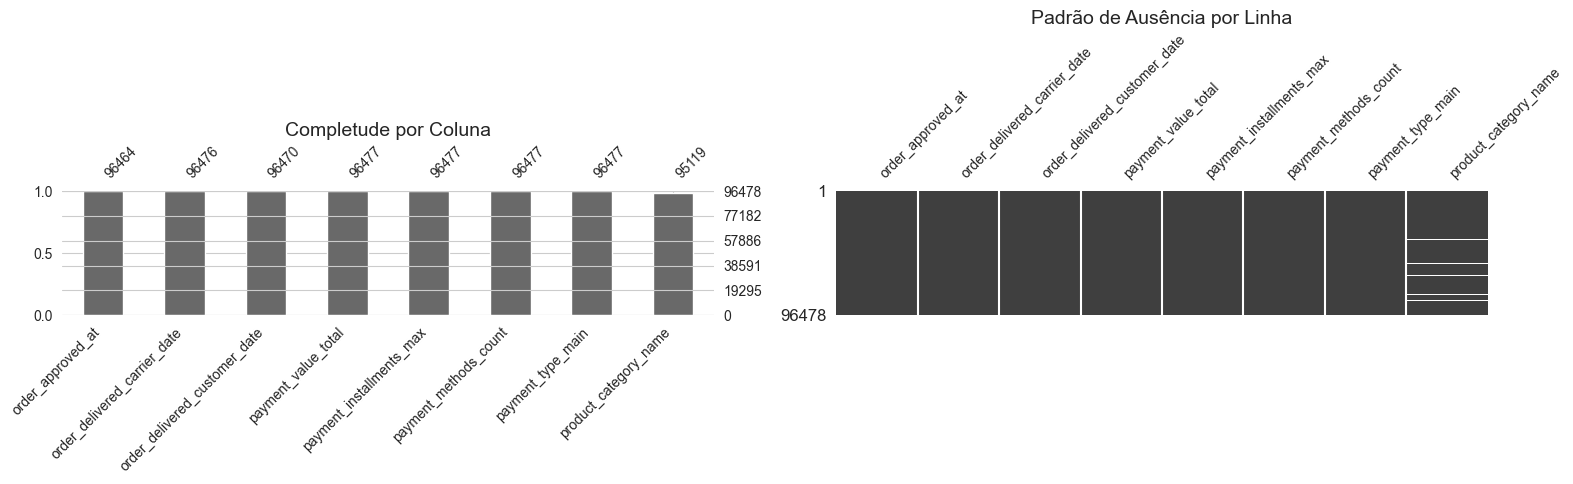

In [15]:
# Visualização do padrão de ausência 
# Colunas numéricas e categóricas relevantes para visualização
cols_analise = [c for c in df.columns if df[c].isnull().sum() > 0]

if len(cols_analise) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    msno.bar(df[cols_analise], ax=axes[0], fontsize=10)
    axes[0].set_title('Completude por Coluna', fontsize=14)
    
    msno.matrix(df[cols_analise], ax=axes[1], fontsize=10)
    axes[1].set_title('Padrão de Ausência por Linha', fontsize=14)
    
    plt.tight_layout()
    plt.show()
else:
    print("Nenhum valor ausente encontrado!")

In [16]:
# Tratamento de ausentes 
## Estratégia baseada na análise acima:

# 1. payment_value_total: ausente = pedido sem pagamento registrado -> remover
if df['payment_value_total'].isnull().sum() > 0:
    n_antes = len(df)
    df = df.dropna(subset=['payment_value_total'])
    print(f"Removidos {n_antes - len(df)} pedidos sem pagamento")

# 2. product_category_name: ausente = categoria não cadastrada -> preencher com 'sem_categoria'
if 'product_category_name' in df.columns:
    df['product_category_name'] = df['product_category_name'].fillna('sem_categoria')
    print(f"Categorias 'sem_categoria': {(df['product_category_name'] == 'sem_categoria').sum()}")

# 3. customer_unique_id: essencial para RFM -> remover se ausente
if df['customer_unique_id'].isnull().sum() > 0:
    n_antes = len(df)
    df = df.dropna(subset=['customer_unique_id'])
    print(f"Removidos {n_antes - len(df)} pedidos sem customer_unique_id")


#  Verificação final de ausentes 
print(f"\nAusentes restantes (colunas-chave RFM): {df[['customer_unique_id', 'order_purchase_date', 'payment_value_total']].isnull().sum().sum()}")
print(f"Shape atual: {df.shape}")

Removidos 1 pedidos sem pagamento
Categorias 'sem_categoria': 1359

Ausentes restantes (colunas-chave RFM): 0
Shape atual: (96477, 22)


### 3.4 Análise de Outliers

Em análise RFM, **outliers** no valor monetário são esperados, `clientes VIP` gastam ordens de magnitude acima da média. Não vamos removê-los, pois **o outlier é justamente o cliente mais valioso**. Segue análise e documentação:

ANÁLISE DE OUTLIERS -- payment_value_total
Média:         R$ 159.86
Mediana:       R$ 105.28
Desvio padrão: R$ 218.81
Skewness:      9.37
Mínimo:        R$ 9.59
Máximo:        R$ 13664.08
Q1:            R$ 61.88
Q3:            R$ 176.33

Limite superior IQR: R$ 348.00
Outliers (acima):    7,576 (7.9%)


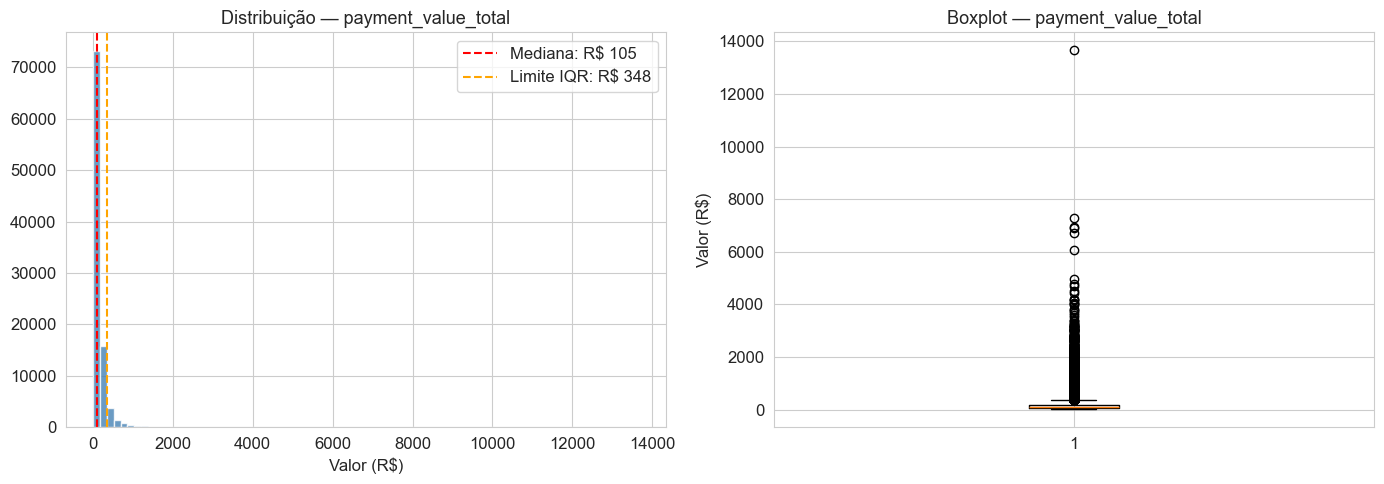

In [17]:
# Análise de outliers na coluna payment_value_total 
col = 'payment_value_total'

print(f"{'=' * 50}")
print(f"ANÁLISE DE OUTLIERS -- {col}")
print(f"{'=' * 50}")
print(f"Média:         R$ {df[col].mean():.2f}")
print(f"Mediana:       R$ {df[col].median():.2f}")
print(f"Desvio padrão: R$ {df[col].std():.2f}")
print(f"Skewness:      {df[col].skew():.2f}")
print(f"Mínimo:        R$ {df[col].min():.2f}")
print(f"Máximo:        R$ {df[col].max():.2f}")
print(f"Q1:            R$ {df[col].quantile(0.25):.2f}")
print(f"Q3:            R$ {df[col].quantile(0.75):.2f}")

# IQR
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

n_outliers = (df[col] > limite_superior).sum()
pct_outliers = n_outliers / len(df) * 100
print(f"\nLimite superior IQR: R$ {limite_superior:.2f}")
print(f"Outliers (acima):    {n_outliers:,} ({pct_outliers:.1f}%)")

# Visualização 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[col], bins=80, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(df[col].median(), color='red', linestyle='--', label=f'Mediana: R$ {df[col].median():.0f}')
axes[0].axvline(limite_superior, color='orange', linestyle='--', label=f'Limite IQR: R$ {limite_superior:.0f}')
axes[0].set_title(f'Distribuição — {col}', fontsize=13)
axes[0].set_xlabel('Valor (R$)')
axes[0].legend()

axes[1].boxplot(df[col], vert=True)
axes[1].set_title(f'Boxplot — {col}', fontsize=13)
axes[1].set_ylabel('Valor (R$)')

plt.tight_layout()
plt.show()

## *Decisão*: 
> Manter os outliers

## *Justificativa*:
R$ 13.664 como máximo é um valor realista e até baixo para e-commerce. Considerando que o Olist vende móveis, eletrodomésticos, cama/mesa/banho, e que um pedido pode ter múltiplos itens, um cliente comprando um sofá + colchão + jogo de cama facilmente passa de R$ 5.000. O skewness de 9.37 é alto, mas esperado a maioria compra itens pequenos (mediana R$ 105), com uma cauda de clientes que gastam mais. Na análise RFM, esses clientes (outliers) são justamente os **VIP** que queremos identificar.

In [18]:
# Remover valores impossíveis 
# Valores ≤ 0 não fazem sentido para transações entregues
n_antes = len(df)
df = df[df['payment_value_total'] > 0].copy()
n_removidos = n_antes - len(df)
if n_removidos > 0:
    print(f"Removidos {n_removidos} registros com payment_value_total ≤ 0")
else:
    print("Nenhum valor ≤ 0 encontrado")
    
print(f"Shape atual: {df.shape}")

Nenhum valor ≤ 0 encontrado
Shape atual: (96477, 22)


### 3.5 Análise Temporal

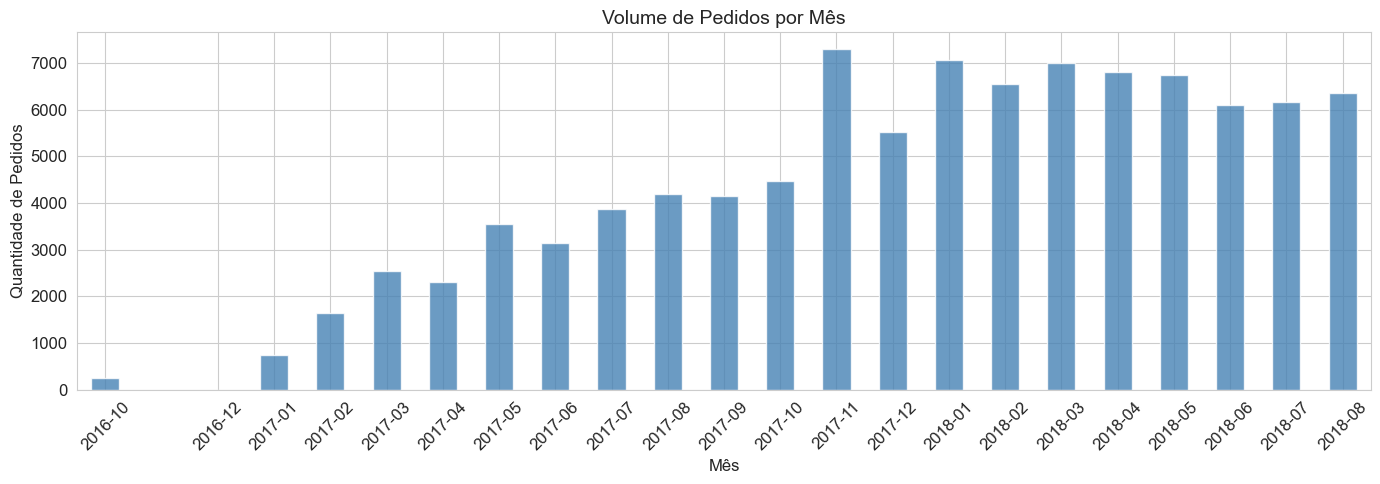

Mês com mais pedidos: 2017-11 (7,289 pedidos)
Mês com menos pedidos: 2016-12 (1 pedidos)


In [19]:
# Pedidos ao longo do tempo 
pedidos_por_mes = df.groupby(df['order_purchase_date'].dt.to_period('M')).size()

fig, ax = plt.subplots(figsize=(14, 5))
pedidos_por_mes.plot(kind='bar', color='steelblue', edgecolor='white', alpha=0.8, ax=ax)
ax.set_title('Volume de Pedidos por Mês', fontsize=14)
ax.set_xlabel('Mês')
ax.set_ylabel('Quantidade de Pedidos')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print(f"Mês com mais pedidos: {pedidos_por_mes.idxmax()} ({pedidos_por_mes.max():,} pedidos)")
print(f"Mês com menos pedidos: {pedidos_por_mes.idxmin()} ({pedidos_por_mes.min():,} pedidos)")

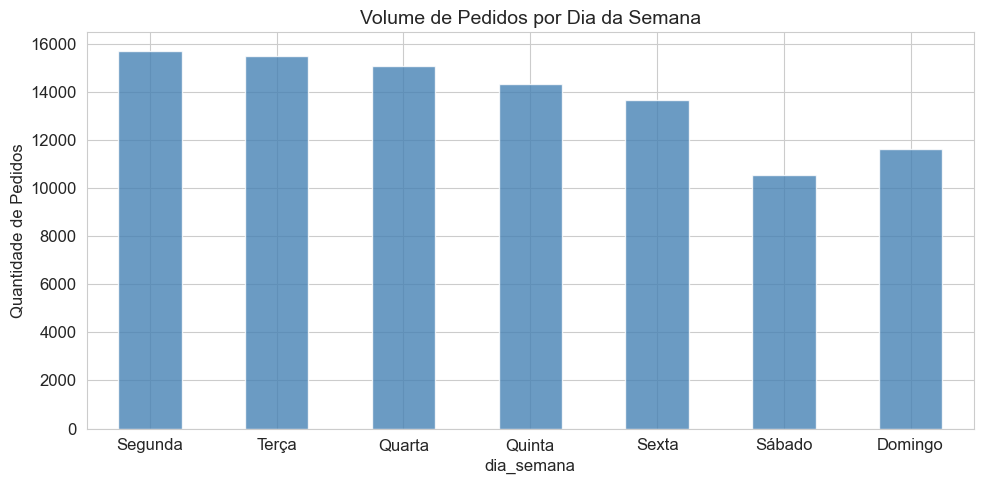

In [20]:
# Pedidos por dia da semana 
dias_semana = {0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta', 
               4: 'Sexta', 5: 'Sábado', 6: 'Domingo'}
df['dia_semana'] = df['order_purchase_timestamp'].dt.dayofweek.map(dias_semana)

pedidos_dia = df['dia_semana'].value_counts().reindex(dias_semana.values())

fig, ax = plt.subplots(figsize=(10, 5))
pedidos_dia.plot(kind='bar', color='steelblue', edgecolor='white', alpha=0.8, ax=ax)
ax.set_title('Volume de Pedidos por Dia da Semana', fontsize=14)
ax.set_ylabel('Quantidade de Pedidos')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

### 3.6 Análise Geográfica (Bônus)

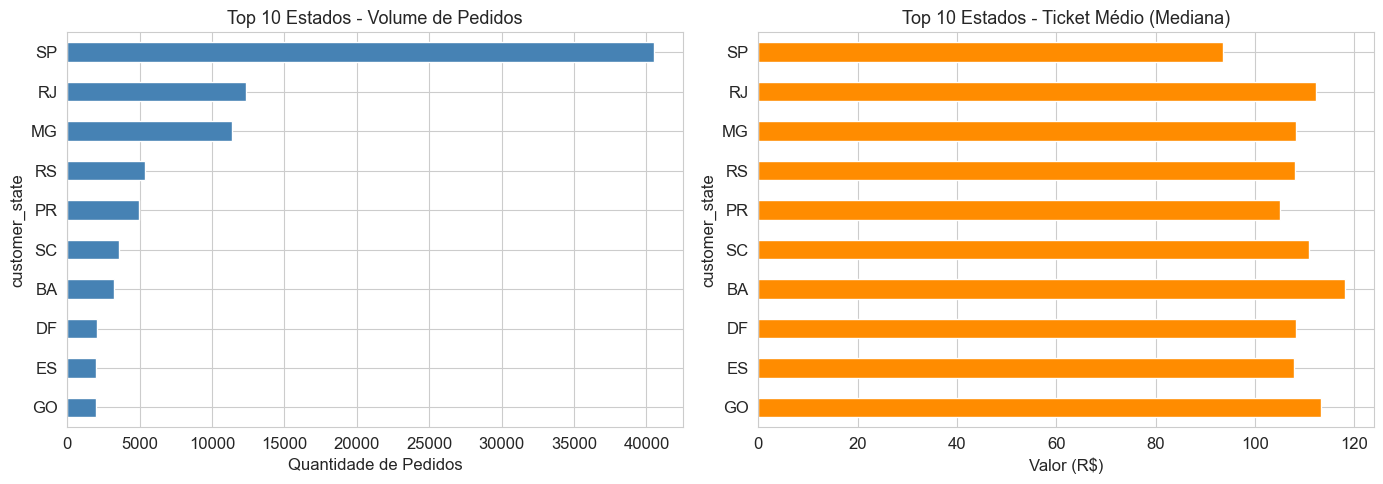

In [21]:
# Top 10 estados por volume de pedidos 
if 'customer_state' in df.columns:
    estados = df['customer_state'].value_counts().head(10)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Volume
    estados.plot(kind='barh', color='steelblue', edgecolor='white', ax=axes[0])
    axes[0].set_title('Top 10 Estados - Volume de Pedidos', fontsize=13)
    axes[0].set_xlabel('Quantidade de Pedidos')
    axes[0].invert_yaxis()
    
    # Ticket médio por estado (top 10 por volume)
    top_estados = estados.index.tolist()
    ticket_estado = df[df['customer_state'].isin(top_estados)].groupby('customer_state')['payment_value_total'].median()
    ticket_estado = ticket_estado.reindex(top_estados)
    
    ticket_estado.plot(kind='barh', color='darkorange', edgecolor='white', ax=axes[1])
    axes[1].set_title('Top 10 Estados - Ticket Médio (Mediana)', fontsize=13)
    axes[1].set_xlabel('Valor (R$)')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()

### 3.7 Relatório de Qualidade - Pré-RFM

In [22]:
# Checklist de qualidade antes do cálculo RFM 
print("=" * 55)
print("RELATÓRIO DE QUALIDADE — PRÉ-RFM")
print("=" * 55)
print(f"Shape:                  {df.shape}")
print(f"Valores ausentes:       {df[['customer_unique_id', 'order_purchase_date', 'payment_value_total']].isnull().sum().sum()}")
print(f"Duplicatas:             {df.duplicated().sum():,}")
print(f"Clientes únicos:        {df['customer_unique_id'].nunique():,}")
print(f"Pedidos únicos:         {df['order_id'].nunique():,}")
print(f"Período:                {df['order_purchase_date'].min().date()} a {df['order_purchase_date'].max().date()}")
print(f"Valor total transações: R$ {df['payment_value_total'].sum():,.2f}")
print(f"Ticket médio:           R$ {df['payment_value_total'].mean():.2f}")
print(f"Mediana do ticket:      R$ {df['payment_value_total'].median():.2f}")
print(f"Memória:                {df.memory_usage(deep=True).sum()/1024**2:.1f} MB")
print("=" * 55)
print("\nDados prontos para cálculo RFM.")

RELATÓRIO DE QUALIDADE — PRÉ-RFM
Shape:                  (96477, 23)
Valores ausentes:       0
Duplicatas:             0
Clientes únicos:        93,357
Pedidos únicos:         96,477
Período:                2016-10-03 a 2018-08-29
Valor total transações: R$ 15,422,461.77
Ticket médio:           R$ 159.86
Mediana do ticket:      R$ 105.28
Memória:                79.2 MB

Dados prontos para cálculo RFM.


## Etapa 4: **Feature Engineering** - Cálculo de R, F e M

Agora vamos agregar os dados por **cliente** para calcular as três métricas:

| Métrica | Cálculo | Lógica |
|---------|---------|--------|
| **Recency** | `data_referência - data_última_compra` | Quanto menor, melhor (comprou recentemente) |
| **Frequency** | `count(order_id)` | Quanto maior, melhor (compra frequentemente) |
| **Monetary** | `sum(payment_value_total)` | Quanto maior, melhor (gasta mais) |

In [23]:
# Data de referência 
# Usamos a data mais recente do dataset + 1 dia como "hoje" (não é o hoje atual: em >= 2026)
data_referencia = df['order_purchase_date'].max() + timedelta(days=1)
print(f"Data de referência (simulando 'hoje'): {data_referencia.date()}")

# Agrupamento por cliente 
df_rfm = df.groupby('customer_unique_id').agg(
    recency=('order_purchase_date', lambda x: (data_referencia - x.max()).days),
    frequency=('order_id', 'nunique'),           # nunique para evitar contar duplicatas
    monetary=('payment_value_total', 'sum')
).reset_index()

# Renomear para maiúsculas (padrão RFM) 
df_rfm.columns = ['customer_unique_id', 'Recency', 'Frequency', 'Monetary']

print(f"\nDataset RFM criado: {df_rfm.shape}")
print(f"Clientes: {df_rfm.shape[0]:,}")
print(f"\nVerificação de NaN: {df_rfm.isnull().sum().sum()}")
df_rfm.head(10)

Data de referência (simulando 'hoje'): 2018-08-30

Dataset RFM criado: (93357, 4)
Clientes: 93,357

Verificação de NaN: 0


,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,538,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,322,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,289,1,196.89
5,0004bd2a26a76fe21f786e4fbd80607f,147,1,166.98
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,35.38
7,00053a61a98854899e70ed204dd4bafe,183,1,419.18
8,0005e1862207bf6ccc02e4228effd9a0,544,1,150.12
9,0005ef4cd20d2893f0d9fbd94d3c0d97,171,1,129.76


In [24]:
# Estatísticas descritivas do RFM 
print("Estatísticas dos Scores RFM:")
print(df_rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2))

print(f"\nTop 5 Insights:")
print(f"• Recency médio: {df_rfm['Recency'].mean():.0f} dias (mediana: {df_rfm['Recency'].median():.0f})")
print(f"• {(df_rfm['Frequency'] == 1).mean()*100:.1f}% dos clientes compraram apenas 1 vez")
print(f"• {(df_rfm['Frequency'] > 1).sum():,} clientes compraram 2+ vezes")
print(f"• Monetary mediano: R$ {df_rfm['Monetary'].median():.2f}")
print(f"• Top 1% dos clientes gastou acima de R$ {df_rfm['Monetary'].quantile(0.99):,.2f}")

Estatísticas dos Scores RFM:
       Recency  Frequency  Monetary
count 93357.00   93357.00  93357.00
mean    238.47       1.03    165.20
std     152.59       0.21    226.31
min       1.00       1.00      9.59
25%     115.00       1.00     63.06
50%     219.00       1.00    107.78
75%     347.00       1.00    182.56
max     696.00      15.00  13664.08

Top 5 Insights:
• Recency médio: 238 dias (mediana: 219)
• 97.0% dos clientes compraram apenas 1 vez
• 2,801 clientes compraram 2+ vezes
• Monetary mediano: R$ 107.78
• Top 1% dos clientes gastou acima de R$ 1,097.06


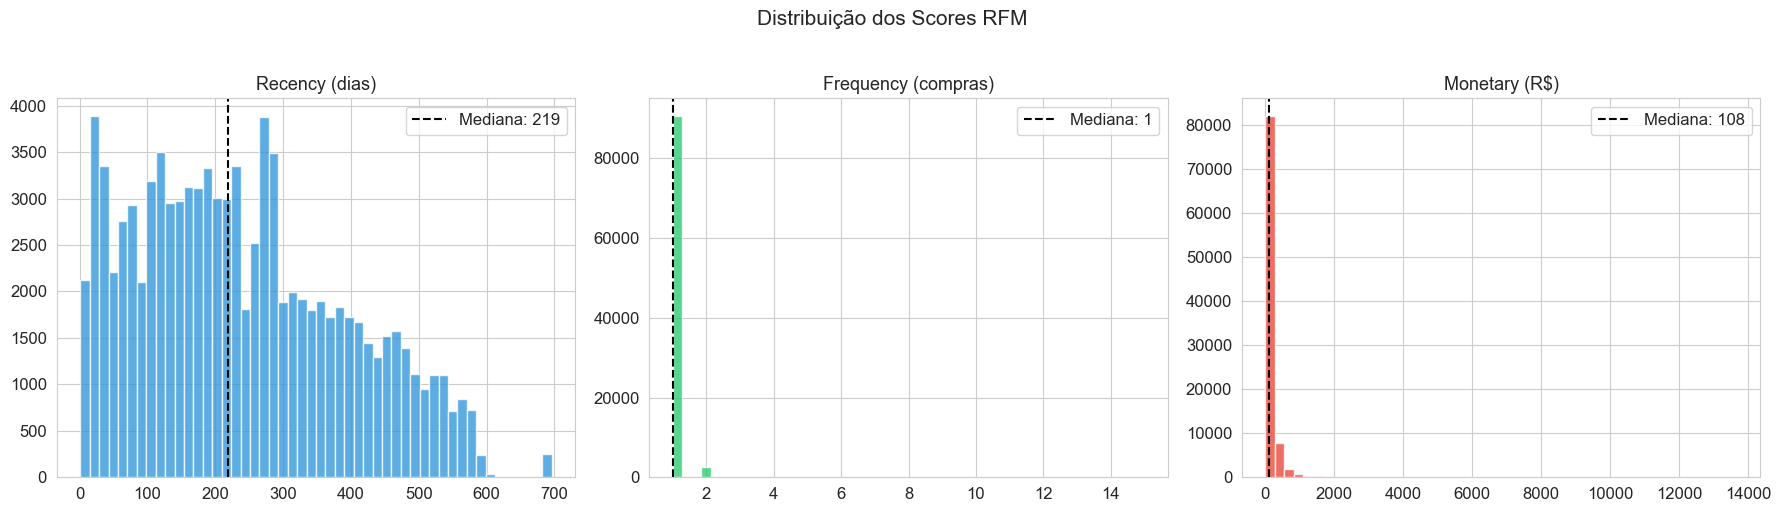

Skewness -> R: 0.45 | F: 11.10 | M: 9.21


In [25]:
# Distribuição visual de R, F, M 
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color, title in zip(axes, 
                                   ['Recency', 'Frequency', 'Monetary'],
                                   ['#3498db', '#2ecc71', '#e74c3c'],
                                   ['Recency (dias)', 'Frequency (compras)', 'Monetary (R$)']):
    ax.hist(df_rfm[col], bins=50, color=color, edgecolor='white', alpha=0.8)
    ax.axvline(df_rfm[col].median(), color='black', linestyle='--', 
               label=f'Mediana: {df_rfm[col].median():.0f}')
    ax.set_title(title, fontsize=13)
    ax.legend()

plt.suptitle('Distribuição dos Scores RFM', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"Skewness -> R: {df_rfm['Recency'].skew():.2f} | F: {df_rfm['Frequency'].skew():.2f} | M: {df_rfm['Monetary'].skew():.2f}")

## **Etapa 5: Segmentação por Quartis (Método Clássico)**

Dividimos cada métrica RFM em **4 quartis** (scores de 1 a 4), onde:
- **Recency:** Score 4 = comprou mais recentemente (melhor) → labels invertidos
- **Frequency:** Score 4 = comprou mais vezes (melhor)
- **Monetary:** Score 4 = gastou mais (melhor)

In [26]:
# Scores por quartis 
# Recency: INVERTIDO — quanto menor o valor (mais recente), maior o score
df_rfm['R'] = pd.qcut(df_rfm['Recency'], q=4, labels=[4, 3, 2, 1]).astype(int)

# Frequency: a maioria comprou 1 vez, então usamos rank percentil
# para evitar erro de bins duplicados no qcut
df_rfm['F'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4]).astype(int)

# Monetary: quanto maior, maior o score
df_rfm['M'] = pd.qcut(df_rfm['Monetary'], q=4, labels=[1, 2, 3, 4]).astype(int)

print("Distribuição dos scores:")
for score in ['R', 'F', 'M']:
    print(f"\n{score}:")
    print(df_rfm[score].value_counts().sort_index())

Distribuição dos scores:

R:
R
1    23268
2    23409
3    23129
4    23551
Name: count, dtype: int64

F:
F
1    23340
2    23339
3    23339
4    23339
Name: count, dtype: int64

M:
M
1    23341
2    23339
3    23338
4    23339
Name: count, dtype: int64


In [27]:
# Score RFM composto 
# Score total (soma): varia de 3 (pior) a 12 (melhor)
df_rfm['RFM_Score'] = df_rfm['R'] + df_rfm['F'] + df_rfm['M']

# Segmento RFM (concatenação): ex: "444" = melhor cliente
df_rfm['RFM_Segment'] = df_rfm['R'].astype(str) + df_rfm['F'].astype(str) + df_rfm['M'].astype(str)

print(f"Score RFM — min: {df_rfm['RFM_Score'].min()} | max: {df_rfm['RFM_Score'].max()}")
print(f"Segmentos únicos: {df_rfm['RFM_Segment'].nunique()}")
print(f"\nDistribuição do Score:")
print(df_rfm['RFM_Score'].value_counts().sort_index())

Score RFM — min: 3 | max: 12
Segmentos únicos: 64

Distribuição do Score:
RFM_Score
3      1517
4      4589
5      8964
6     14476
7     17466
8     16928
9     14160
10     8871
11     4594
12     1792
Name: count, dtype: int64


In [28]:
# Classificação dos segmentos de clientes 
def classificar_cliente(row):
    r, f, m, score = row['R'], row['F'], row['M'], row['RFM_Score']
    
    if score >= 10:
        return 'VIP'
    elif score >= 8 and m >= 3:
        return 'Leais Alto Valor'
    elif f >= 3:
        return 'Leais Frequentes'
    elif r >= 3 and f <= 2:
        return 'Novos Promissores'
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Em Risco'
    elif r == 1:
        return 'Quase Perdidos'
    else:
        return 'Precisam de Atenção'

df_rfm['Segmento'] = df_rfm.apply(classificar_cliente, axis=1)

# Ações de marketing por segmento 
acoes_marketing = {
    'VIP':                  'Programas de fidelidade exclusivos; acesso antecipado a lançamentos; atendimento premium',
    'Leais Alto Valor':     'Upsell de produtos premium; programa de pontos; ofertas personalizadas',
    'Leais Frequentes':     'Cross-sell; programa de indicação com benefícios; newsletter exclusiva',
    'Novos Promissores':    'Onboarding personalizado; cupom de segunda compra; educação sobre catálogo',
    'Precisam de Atenção':  'Campanhas de reengajamento; pesquisa de satisfação; ofertas com urgência',
    'Em Risco':             'Win-back com desconto agressivo; email de "sentimos sua falta"; pesquisa de NPS',
    'Quase Perdidos':       'Última tentativa de reativação; desconto máximo; avaliar custo de aquisição vs. retenção'
}

df_rfm['Acao_Marketing'] = df_rfm['Segmento'].map(acoes_marketing)

print("Distribuição de clientes por segmento:")
print(df_rfm['Segmento'].value_counts())
print(f"\nPercentual:")
print((df_rfm['Segmento'].value_counts(normalize=True) * 100).round(1))

Distribuição de clientes por segmento:
Segmento
Leais Frequentes       22878
Leais Alto Valor       19978
VIP                    15257
Novos Promissores      13212
Em Risco               12157
Quase Perdidos          5561
Precisam de Atenção     4314
Name: count, dtype: int64

Percentual:
Segmento
Leais Frequentes      24.50
Leais Alto Valor      21.40
VIP                   16.30
Novos Promissores     14.20
Em Risco              13.00
Quase Perdidos         6.00
Precisam de Atenção    4.60
Name: proportion, dtype: float64


In [29]:
# Perfil médio de cada segmento
perfil = df_rfm.groupby('Segmento').agg(
    Clientes=('customer_unique_id', 'count'),
    R_medio=('Recency', 'mean'),
    F_medio=('Frequency', 'mean'),
    M_medio=('Monetary', 'mean'),
    M_total=('Monetary', 'sum'),
    Score_medio=('RFM_Score', 'mean')
).round(1)

perfil['% Clientes'] = (perfil['Clientes'] / perfil['Clientes'].sum() * 100).round(1)
perfil['% Receita'] = (perfil['M_total'] / perfil['M_total'].sum() * 100).round(1)
perfil = perfil.sort_values('M_total', ascending=False)

print("PERFIL DOS SEGMENTOS RFM")
print("=" * 90)
perfil

PERFIL DOS SEGMENTOS RFM


,Clientes,R_medio,F_medio,M_medio,M_total,Score_medio,% Clientes,% Receita
Segmento,,,,,,,,
Leais Alto Valor,19978,235.00,1.00,262.00,5235084.90,8.50,21.40,33.90
VIP,15257,115.50,1.10,292.00,4454993.70,10.50,16.30,28.90
Leais Frequentes,22878,265.20,1.00,67.20,1538288.70,7.30,24.50,10.00
Quase Perdidos,5561,452.70,1.00,269.80,1500314.00,6.00,6.00,9.70
Precisam de Atenção,4314,277.60,1.00,224.10,966750.10,6.70,4.60,6.30
Novos Promissores,13212,119.10,1.00,72.10,952272.30,6.60,14.20,6.20
Em Risco,12157,366.10,1.00,63.70,774758.00,4.50,13.00,5.00


In [30]:
# Treemap interativo dos segmentos 
treemap_data = perfil.reset_index()
treemap_data['Label'] = (treemap_data['Segmento'].apply(lambda x: f'<b>{x}</b>') + '<br>' + 
                         treemap_data['Clientes'].apply(lambda x: f'{x:,} clientes') + '<br>' +
                         treemap_data['% Clientes'].apply(lambda x: f'{x}% da base') + '<br>' +
                         treemap_data['% Receita'].apply(lambda x: f'{x}% da receita'))
 
fig = px.treemap(
    treemap_data,
    path=['Label'],
    values='Clientes',
    title='Segmentação RFM — Proporção de Clientes por Segmento'
)
 
fig.update_traces(
    marker=dict(
        colors=['#1a5632', '#217a45', '#28a05a', '#3bbf73', '#6dd49a', '#a0e4bb', '#c8f0d8'],
        line=dict(color='white', width=2)
    ),
    textinfo='label',
    textfont=dict(size=14, color='black')
)
 
fig.update_layout(
    width=900, 
    height=600,
    title_font_size=16,
    margin=dict(t=50, l=10, r=10, b=10)
)
 
fig.show()

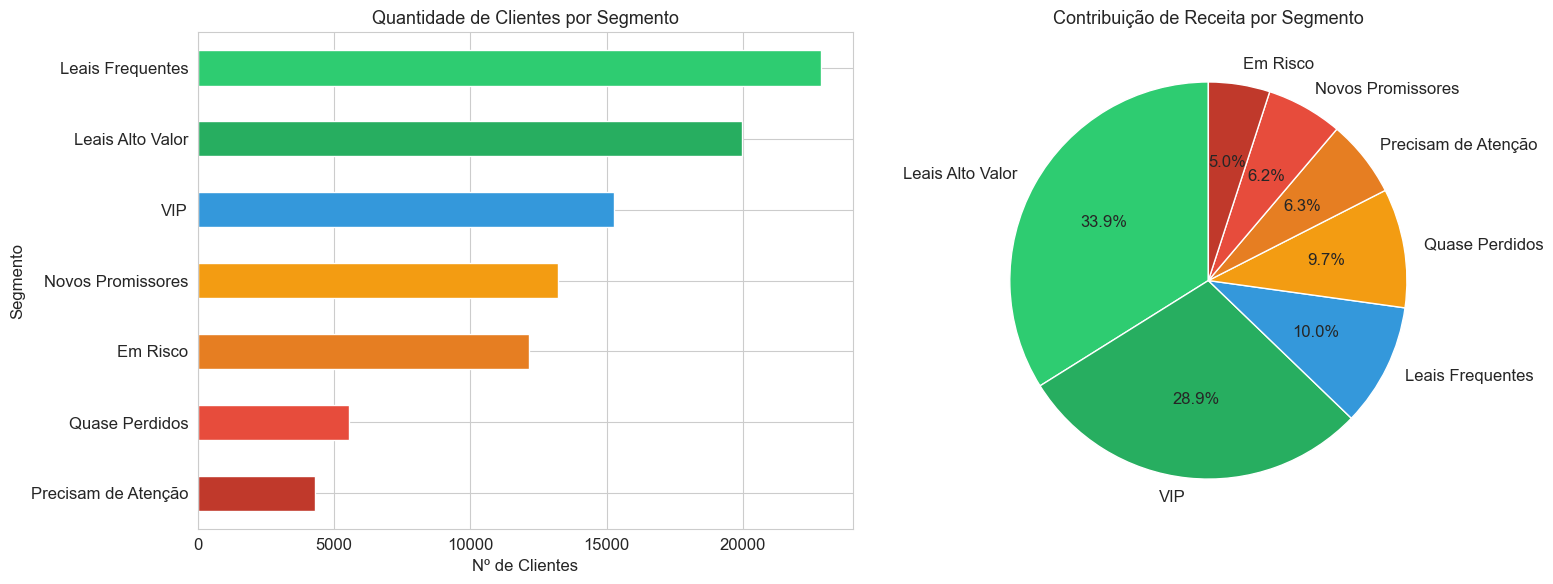


📊 Insight: Top 2 segmentos respondem por 62.8% da receita total


In [31]:
# Visualização: distribuição de receita por segmento
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barras: Clientes por segmento
segmentos_ordenados = df_rfm['Segmento'].value_counts()
colors = ['#2ecc71', '#27ae60', '#3498db', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']
segmentos_ordenados.plot(kind='barh', ax=axes[0], color=colors[:len(segmentos_ordenados)], edgecolor='white')
axes[0].set_title('Quantidade de Clientes por Segmento', fontsize=13)
axes[0].set_xlabel('Nº de Clientes')
axes[0].invert_yaxis()

# Pizza: % da receita por segmento
perfil['% Receita'].plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                          colors=colors[:len(perfil)], startangle=90)
axes[1].set_title('Contribuição de Receita por Segmento', fontsize=13)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f"\n📊 Insight: Top 2 segmentos respondem por {perfil['% Receita'].head(2).sum():.1f}% da receita total")

## **Etapa 6: `Segmentação por K-Means` (Método Alternativo -- Bônus)**

Além da segmentação por quartis (baseada em regras), aplicamos **K-Means clustering** para descobrir agrupamentos naturais nos dados RFM.

**Vantagens do K-Means vs. Quartis:**
- Encontra padrões que regras manuais podem não captar
- Não assume distribuição uniforme entre segmentos
- Escalável para inclusão de novas features

**Etapas:**
1. Normalizar R, F, M (StandardScaler)
2. Método do Cotovelo (Elbow) para escolher o número ideal de clusters
3. Silhouette Score para validar a qualidade
4. Comparar com a segmentação por quartis

In [32]:
# Normalização 
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df_rfm[['Recency', 'Frequency', 'Monetary']])

print(f"Shape normalizado: {rfm_scaled.shape}")
print(f"Médias (devem ser ~0): {rfm_scaled.mean(axis=0).round(4)}")
print(f"Desvios (devem ser ~1): {rfm_scaled.std(axis=0).round(4)}")

Shape normalizado: (93357, 3)
Médias (devem ser ~0): [-0. -0. -0.]
Desvios (devem ser ~1): [1. 1. 1.]


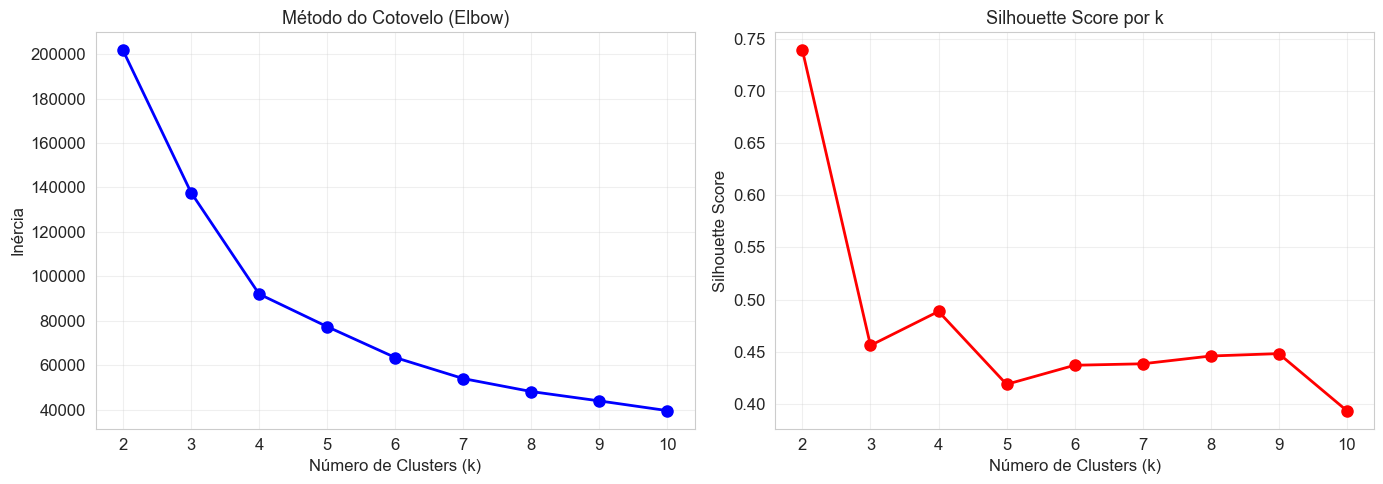


Melhor k pelo Silhouette Score: 2 (score: 0.7389)


In [33]:
# Método do Cotovelo (Elbow Method)
inertias = []
silhouettes = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(rfm_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_title('Método do Cotovelo (Elbow)', fontsize=13)
axes[0].set_xlabel('Número de Clusters (k)')
axes[0].set_ylabel('Inércia')
axes[0].grid(True, alpha=0.3)

# Silhouette
axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_title('Silhouette Score por k', fontsize=13)
axes[1].set_xlabel('Número de Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"\nMelhor k pelo Silhouette Score: {best_k} (score: {max(silhouettes):.4f})")

In [34]:
# Aplicando o K-Means com base no resultado do método do cotovelo
k_final = 2

kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
df_rfm['Cluster_KMeans'] = kmeans_final.fit_predict(rfm_scaled)

print(f"K-Means com k={k_final}:")
print(df_rfm['Cluster_KMeans'].value_counts().sort_index())

# Perfil dos clusters 
perfil_kmeans = df_rfm.groupby('Cluster_KMeans').agg(
    Clientes=('customer_unique_id', 'count'),
    R_medio=('Recency', 'mean'),
    F_medio=('Frequency', 'mean'),
    M_medio=('Monetary', 'mean'),
    M_total=('Monetary', 'sum')
).round(1)

perfil_kmeans['% Clientes'] = (perfil_kmeans['Clientes'] / perfil_kmeans['Clientes'].sum() * 100).round(1)
perfil_kmeans['% Receita'] = (perfil_kmeans['M_total'] / perfil_kmeans['M_total'].sum() * 100).round(1)

print(f"\nPerfil dos Clusters K-Means:")
perfil_kmeans

K-Means com k=2:
Cluster_KMeans
0     2810
1    90547
Name: count, dtype: int64

Perfil dos Clusters K-Means:


,Clientes,R_medio,F_medio,M_medio,M_total,% Clientes,% Receita
Cluster_KMeans,,,,,,,
0,2810,220.90,2.10,329.50,925915.30,3.00,6.00
1,90547,239.00,1.00,160.10,14496546.40,97.00,94.00


### **Análise Comparativa: `Quartis` vs `K-Means`**

O K-Means com k=2 (melhor Silhouette Score: 0.74) encontrou uma separação estatisticamente nítida, mas pouco granular para ações de marketing: o algoritmo essencialmente dividiu a base entre **clientes recorrentes (3%)** e **clientes de compra única (97%)**.

Isso ocorre porque 97% da base tem Frequency = 1, criando uma estrutura de dados onde a separação mais natural é binária.

| Critério | Quartis (7 segmentos) | K-Means (k=2) |
|----------|----------------------|----------------|
| **Granularidade** | Alta — 7 perfis distintos | Baixa — apenas 2 grupos |
| **Base estatística** | Regras de negócio + quartis | Distância euclidiana nos dados |
| **Acionabilidade** | Alta — cada segmento tem ação específica | Baixa — "recorrente vs não recorrente" |
| **Validação** | Interpretação de negócio | Silhouette Score: 0.74 |
| **Melhor para** | Decisões de marketing | Confirmar estrutura dos dados |

**Conclusão:** Para este dataset, a **segmentação por quartis é mais adequada para decisões de marketing**, pois diferencia perfis dentro da massa de clientes de compra única usando Recency e Monetary como critérios adicionais. O K-Means valida que **a recorrência é o fator mais discriminante da base**  informação estratégica para a política de retenção.

In [35]:
# Visualização 3D dos clusters (Plotly) 
fig = px.scatter_3d(
    df_rfm, 
    x='Recency', 
    y='Frequency', 
    z='Monetary',
    color='Cluster_KMeans',
    title='Clusters K-Means — Espaço RFM 3D',
    labels={'Recency': 'Recency (dias)', 'Frequency': 'Frequency (compras)', 
            'Monetary': 'Monetary (R$)'},
    opacity=0.5,
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.update_layout(width=900, height=700)
fig.show()

## **Resumo Executivo - Plano de Ação por Segmento**

> Tabela consolidada para a área de Marketing com perfil de cada segmento e ação recomendada.

| Segmento | Clientes | % Base | % Receita | Ticket Médio | Recency Médio | Ação Recomendada |
|----------|----------|--------|-----------|-------------|---------------|------------------|
| **VIP** | 15.257 | 16,3% | 28,9% | R$ 292 | 115 dias | Programa de fidelidade exclusivo; acesso antecipado a lançamentos; atendimento premium personalizado |
| **Leais Alto Valor** | 19.978 | 21,4% | 33,9% | R$ 262 | 235 dias | Upsell de produtos premium; programa de pontos acumulativos; ofertas personalizadas por categoria |
| **Leais Frequentes** | 22.878 | 24,5% | 10,0% | R$ 67 | 265 dias | Cross-sell para aumentar ticket; programa de indicação com benefícios; newsletter com curadoria |
| **Novos Promissores** | 13.212 | 14,2% | 6,2% | R$ 72 | 119 dias | Onboarding personalizado; cupom de 2ª compra com urgência (30 dias); educação sobre catálogo completo |
| **Precisam de Atenção** | 4.314 | 4,6% | 6,3% | R$ 224 | 278 dias | Campanhas de reengajamento; pesquisa de satisfação; ofertas com prazo limitado |
| **Em Risco** | 12.157 | 13,0% | 5,0% | R$ 64 | 366 dias | Win-back com desconto agressivo (15-20%); email "sentimos sua falta"; pesquisa de NPS |
| **Quase Perdidos** | 5.561 | 6,0% | 9,7% | R$ 270 | 453 dias | Última tentativa de reativação com desconto máximo; avaliar se custo de retenção < custo de nova aquisição |

### Priorização de Investimento de Marketing

🟢 **Prioridade #1 — Proteger a receita existente (62,8% da receita)**
- VIP + Leais Alto Valor = 37,7% da base mas 62,8% da receita
- Ação: Programa de fidelidade + upsell personalizado
- ROI esperado: Alto (reter 1 cliente VIP > adquirir 4 novos)

🟡 **Prioridade #2 — Converter Novos Promissores (14,2% da base)**
- Compraram recentemente (119 dias) mas ticket baixo (R$ 72)
- Ação: Cupom de 2ª compra + cross-sell de categorias complementares
- ROI esperado: Médio (potencial de migrar para Leais)

🔴 **Prioridade #3 — Reativar clientes de alto valor perdidos (9,7% da receita)**
- Quase Perdidos: apenas 6% da base mas 9,7% da receita (ticket R$ 270!)
- Ação: Campanha de win-back agressiva — esses clientes gastavam bem
- ROI esperado: Médio-Alto (se reativados, voltam como alto valor)

## **Etapa 7: Exportação dos Resultados**

In [36]:
# Salvando dataset RFM para Power BI 
df_rfm.to_csv('rfm_segmentado.csv', index=False, encoding='utf-8-sig')
print(f" Arquivo salvo: rfm_segmentado.csv ({df_rfm.shape[0]:,} clientes)")

# Salvando perfil dos segmentos 
perfil.to_csv('perfil_segmentos.csv', encoding='utf-8-sig')
print(f" Arquivo salvo: perfil_segmentos.csv")

 Arquivo salvo: rfm_segmentado.csv (93,357 clientes)
 Arquivo salvo: perfil_segmentos.csv


## **Etapa 8: Conclusões e Próximos Passos**

### Principais Descobertas

**Estrutura da base:**
- **93.357 clientes** analisados ao longo de **773 dias** (Set/2016 — Ago/2018)
- **97% dos clientes compraram apenas 1 vez** a **`recorrência é o maior desafio do marketplace`**
- Apenas **2.801 clientes** (3%) realizaram 2 ou mais compras
- Valor total de transações: **R$ 15,4 milhões** com ticket médio de **R$ 159,86**

**Segmentação RFM (7 segmentos por quartis):**
- **VIP (16,3%) + Leais Alto Valor (21,4%) = 37,7% da base → 62,8% da receita**
- O ticket médio dos VIP (**R$ 292**) é **4,6x maior** que o dos clientes Em Risco (**R$ 64**)
- **Quase Perdidos** são apenas 6% da base mas respondem por **9,7% da receita** — alto valor sendo perdido
- **Novos Promissores** (14,2% da base) compraram recentemente mas com ticket baixo — oportunidade de conversão

**Segmentação K-Means (k=2, Silhouette: 0.74):**
- Confirmou que a separação mais natural dos dados é **recorrentes vs não recorrentes**
- Valida que a estratégia de retenção/recompra deve ser prioridade #1 do marketing

### Recomendações Estratégicas para Marketing

1. **Programa de Fidelidade** para VIP e Leais Alto Valor -- proteger 62,8% da receita com benefícios exclusivos, acesso antecipado e atendimento diferenciado

2. **Automação de Recompra** para Novos Promissores -- cupom de segunda compra com prazo de 30 dias, cross-sell baseado na categoria da primeira compra

3. **Campanha de Win-back** para Quase Perdidos -- esses clientes tinham ticket médio de R$ 270; reativá-los tem ROI potencialmente maior que adquirir novos clientes

4. **Análise de churn preventivo** -- com 97% de compra única, entender por que clientes não voltam é mais valioso que segmentar os que voltam

### Limitações

- Dataset de **2016-2018**. Os padrões de consumo no e-commerce brasileiro mudaram significativamente desde então (pandemia, PIX, crescimento do marketplace)
- **Sem dados de custo de aquisição (CAC)** -- impossível calcular ROI real por campanha de retenção vs aquisição
- **RFM não captura satisfação** -- integrar dados de review (disponíveis no dataset Olist) enriqueceria a segmentação
- **Frequency muito concentrada em 1** -- a análise RFM é mais poderosa em negócios com recorrência natural (SaaS, supermercados, assinaturas)

---

*Projeto desenvolvido por Lucas Coutinho Boros | Ciência de Dados & IA*

*Dataset: [Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce) — Kaggle*

*GitHub: [Lucas-Coutinhob](https://github.com/Lucas-Coutinhob) | LinkedIn: [lucas-coutinho-boros](https://linkedin.com/in/lucas-coutinho-boros)*
